# 03 — Model Comparison

Сравнение всех моделей по prediction CSV из `main.py`.

**Требуется**: сначала запустить `main.py`

In [1]:
from pathlib import Path
import sys
ROOT = next(
    str(p) for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    if (p / 'config.yaml').exists()
)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from thesis_app.notebook_helpers import apply_thesis_plot_style, preferred_xgb_label, best_ml_model_name, significance_stars, interpretation_text
apply_thesis_plot_style()


## Interpretation focus
Use this notebook to answer which models forecast intermarket dependency most reliably across assets and rolling windows. For the thesis text, emphasize consistency across experiments, not only the single best score.

In [2]:
from pathlib import Path
import sys
ROOT = next(
    str(p) for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    if (p / 'config.yaml').exists()
)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import sys, os


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from thesis_app.pipeline import load_config, build_paths, metrics_to_latex

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

cfg   = load_config(os.path.join(ROOT, 'config.yaml'))
paths = build_paths(ROOT)
print('Predictions dir:', paths.predictions)


Predictions dir: D:\clear\outputs\predictions


In [3]:
# ── Load all prediction CSVs ─────────────────────────────────
csv_files = sorted(glob(os.path.join(paths.predictions, '*_predictions.csv')))
print(f'Found {len(csv_files)} prediction files')

experiments = {}
for f in csv_files:
    name = os.path.basename(f).replace('_predictions.csv', '')
    experiments[name] = pd.read_csv(f, index_col=0, parse_dates=True)

list(experiments.keys())


Found 24 prediction files


['corr_BTC-USD_ETH-USD_w14_fisher_z',
 'corr_BTC-USD_ETH-USD_w30_fisher_z',
 'corr_BTC-USD_ETH-USD_w60_fisher_z',
 'corr_BTC-USD_ETH-USD_w90_fisher_z',
 'corr_BTC-USD_GLD_w14_fisher_z',
 'corr_BTC-USD_GLD_w30_fisher_z',
 'corr_BTC-USD_GLD_w60_fisher_z',
 'corr_BTC-USD_GLD_w90_fisher_z',
 'corr_BTC-USD_SLV_w14_fisher_z',
 'corr_BTC-USD_SLV_w30_fisher_z',
 'corr_BTC-USD_SLV_w60_fisher_z',
 'corr_BTC-USD_SLV_w90_fisher_z',
 'corr_BTC-USD_UUP_w14_fisher_z',
 'corr_BTC-USD_UUP_w30_fisher_z',
 'corr_BTC-USD_UUP_w60_fisher_z',
 'corr_BTC-USD_UUP_w90_fisher_z',
 'corr_BTC-USD_^GSPC_w14_fisher_z',
 'corr_BTC-USD_^GSPC_w30_fisher_z',
 'corr_BTC-USD_^GSPC_w60_fisher_z',
 'corr_BTC-USD_^GSPC_w90_fisher_z',
 'corr_BTC-USD_^IXIC_w14_fisher_z',
 'corr_BTC-USD_^IXIC_w30_fisher_z',
 'corr_BTC-USD_^IXIC_w60_fisher_z',
 'corr_BTC-USD_^IXIC_w90_fisher_z']

In [4]:
# ── Metrics for all experiments ───────────────────────────────
rows = []
for key, df in experiments.items():
    y_true = df['y_true'].dropna()
    parts = key.split('_w')
    dep_part = parts[0]
    w_space_parts = parts[1].split('_', 1) if len(parts) > 1 else ['0', 'unknown']
    window = int(w_space_parts[0]) if w_space_parts[0].isdigit() else 0
    space = w_space_parts[1] if len(w_space_parts) > 1 else 'unknown'

    for model in [c for c in df.columns if c != 'y_true']:
        pred = df[model].dropna()
        common = y_true.index.intersection(pred.index)
        if len(common) < 50:
            continue
        yt = y_true.loc[common].values
        yp = pred.loc[common].values
        rows.append({
            'experiment': key, 'dependency': dep_part, 'window': window,
            'space': space, 'model': model,
            'MAE':  float(mean_absolute_error(yt, yp)),
            'RMSE': float(np.sqrt(mean_squared_error(yt, yp))),
            'R2':   float(r2_score(yt, yp)),
            'n':    len(common),
        })

metrics = pd.DataFrame(rows)
print(f'Total rows: {len(metrics)}')
metrics.head()


Total rows: 216


,experiment,dependency,window,space,model,MAE,RMSE,R2,n
0,corr_BTC-USD_ETH-USD_w14_fisher_z,corr_BTC-USD_ETH-USD,14,fisher_z,Naive_Last,0.097489,0.154569,0.878929,2177
1,corr_BTC-USD_ETH-USD_w14_fisher_z,corr_BTC-USD_ETH-USD,14,fisher_z,AR1,0.100401,0.152830,0.881639,2177
2,corr_BTC-USD_ETH-USD_w14_fisher_z,corr_BTC-USD_ETH-USD,14,fisher_z,ElasticNet,0.102859,0.151625,0.883498,2177
3,corr_BTC-USD_ETH-USD_w14_fisher_z,corr_BTC-USD_ETH-USD,14,fisher_z,Ridge,0.101762,0.150794,0.884772,2177
4,corr_BTC-USD_ETH-USD_w14_fisher_z,corr_BTC-USD_ETH-USD,14,fisher_z,RF,0.137755,0.187019,0.822759,2177


In [5]:
# ── Best model per experiment ────────────────────────
BASELINES = ('Naive_Last', 'AR1', 'DCC_GARCH')
ML_MODELS = [m for m in metrics['model'].unique() if m not in BASELINES]
ml_metrics = metrics[metrics['model'].isin(ML_MODELS)]
best_per_exp = ml_metrics.loc[ml_metrics.groupby('experiment')['RMSE'].idxmin()]
print(best_per_exp[['dependency','window','model','RMSE','R2']].to_string(index=False))


          dependency  window model     RMSE       R2
corr_BTC-USD_ETH-USD      14 Ridge 0.150794 0.884772
corr_BTC-USD_ETH-USD      30 Ridge 0.069895 0.959729
corr_BTC-USD_ETH-USD      60 Ridge 0.034715 0.986071
corr_BTC-USD_ETH-USD      90 Ridge 0.023496 0.991850
    corr_BTC-USD_GLD      14 Ridge 0.139868 0.863265
    corr_BTC-USD_GLD      30 Ridge 0.066776 0.933996
    corr_BTC-USD_GLD      60 Ridge 0.034484 0.969303
    corr_BTC-USD_GLD      90 Ridge 0.023316 0.980609
    corr_BTC-USD_SLV      14 Ridge 0.139809 0.856369
    corr_BTC-USD_SLV      30 Ridge 0.062540 0.940028
    corr_BTC-USD_SLV      60 Ridge 0.032010 0.972438
    corr_BTC-USD_SLV      90 Ridge 0.022227 0.981530
    corr_BTC-USD_UUP      14 Ridge 0.140672 0.881944
    corr_BTC-USD_UUP      30 Ridge 0.066617 0.943938
    corr_BTC-USD_UUP      60 Ridge 0.033591 0.973613
    corr_BTC-USD_UUP      90 Ridge 0.022276 0.983825
  corr_BTC-USD_^GSPC      14 Ridge 0.139199 0.861843
  corr_BTC-USD_^GSPC      30 Ridge 0.065073 0.

RMSE table (corr_BTC-USD_^GSPC):
window          14      30      60      90
model                                     
AR1         0.1428  0.0650  0.0317  0.0217
DCC_GARCH   0.3284  0.1937  0.1210  0.0982
ElasticNet  0.1406  0.0664  0.0335  0.0237
Ensemble    0.1608  0.0776  0.0435  0.0317
GBM         0.1780  0.0875  0.0495  0.0331
Naive_Last  0.1449  0.0653  0.0318  0.0217
RF          0.1845  0.0909  0.0534  0.0348
Ridge       0.1392  0.0651  0.0320  0.0221
XGB_GPU     0.2175  0.1139  0.0876  0.0794


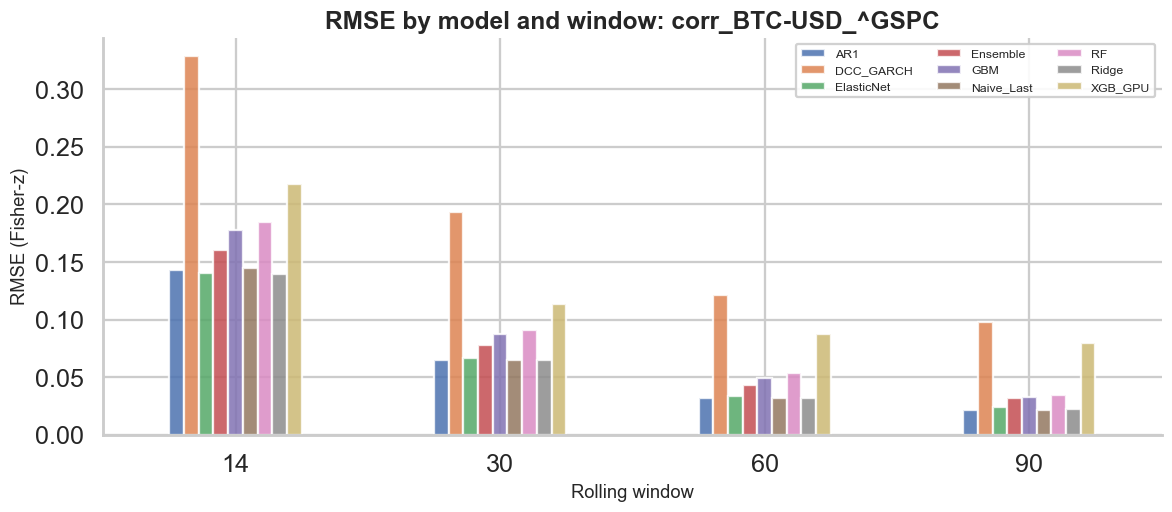

In [6]:
# ── RMSE comparison for one pair ───────────────────────────────
DEP = 'corr_BTC-USD_^GSPC'
sub = metrics[metrics['dependency'] == DEP].copy()
pivot = sub.pivot_table(index='model', columns='window', values='RMSE')
print(f'RMSE table ({DEP}):')
print(pivot.round(4))

fig, ax = plt.subplots(figsize=(11, 5))
pivot.T.plot(kind='bar', ax=ax, alpha=0.85)
ax.set_title(f'RMSE by model and window: {DEP}')
ax.set_xlabel('Rolling window')
ax.set_ylabel('RMSE (Fisher-z)')
ax.legend(ncol=3, fontsize=8)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, f'model_rmse_comparison.png'), dpi=130)
plt.show()


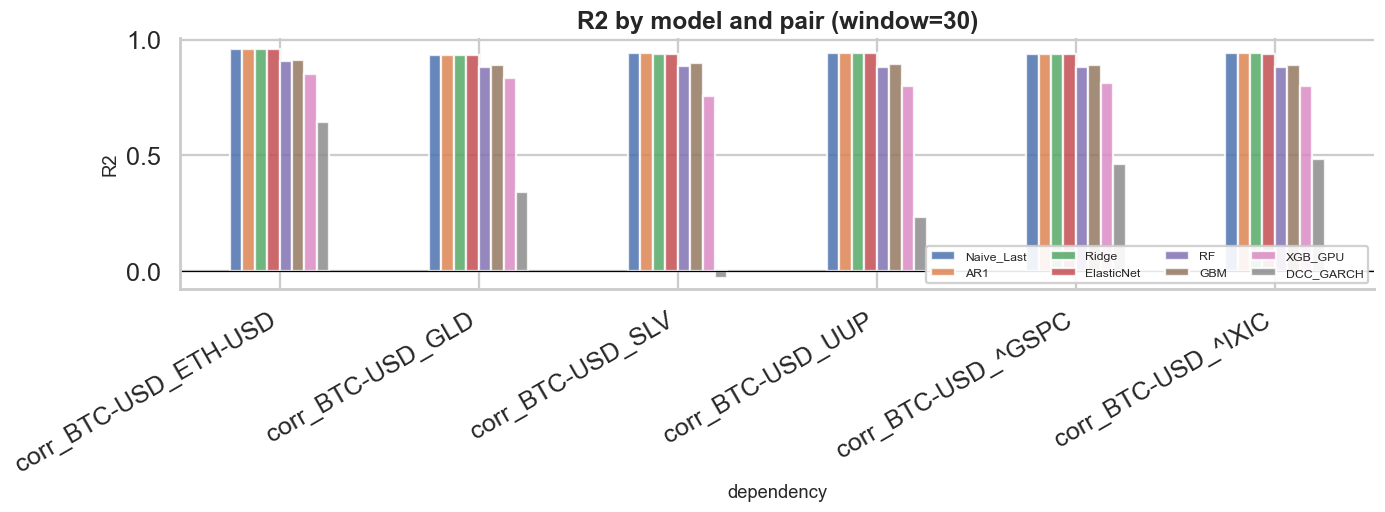

Interpretation: higher R2 indicates stronger practical usefulness in the out-of-sample setting.


In [7]:
# ── R2 comparison, window=30 ─────────────────────────────────────
W = 30
model_order = [m for m in ['Naive_Last', 'AR1', 'Ridge', 'ElasticNet', 'RF', 'GBM', 'XGB_GPU', 'XGB_CPU', 'DCC_GARCH'] if m in metrics['model'].unique()]
available = [m for m in model_order if m in metrics['model'].unique()]

sub30 = metrics[metrics['window'] == W].copy()
pivot_r2 = sub30.pivot_table(index='dependency', columns='model', values='R2')[available]

fig, ax = plt.subplots(figsize=(13, 5))
pivot_r2.plot(kind='bar', ax=ax, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_title(f'R2 by model and pair (window={W})')
ax.set_ylabel('R2')
ax.legend(ncol=4, fontsize=8, loc='lower right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, f'model_r2_comparison_w{W}.png'), dpi=130)
plt.show()

print(interpretation_text('R2', higher_is_better=True))


In [8]:
# ── Overall ranking by mean RMSE ───────────────────────────────
ranking = metrics.groupby('model')[['RMSE','MAE','R2']].mean().sort_values('RMSE').round(4)
print('Mean metrics across all experiments:')
print(ranking.to_string())

metrics.to_csv(os.path.join(paths.results, 'metrics_all_models.csv'), index=False)
ranking.to_csv(os.path.join(paths.results, 'model_ranking.csv'))
print('Saved.')


Mean metrics across all experiments:
              RMSE     MAE      R2
model                             
Ridge       0.0656  0.0419  0.9432
AR1         0.0659  0.0403  0.9424
Naive_Last  0.0666  0.0395  0.9412
ElasticNet  0.0669  0.0434  0.9411
Ensemble    0.0787  0.0549  0.9194
GBM         0.0875  0.0616  0.9007
RF          0.0905  0.0636  0.8936
XGB_GPU     0.1241  0.0864  0.7923
DCC_GARCH   0.2127  0.1677  0.3752
Saved.


     model  mean_improvement_%  n
     Ridge               -0.05 24
ElasticNet               -3.47 24
  Ensemble              -28.84 24
       GBM              -43.70 24
        RF              -48.94 24
   XGB_GPU             -138.91 24
 DCC_GARCH             -308.30 24


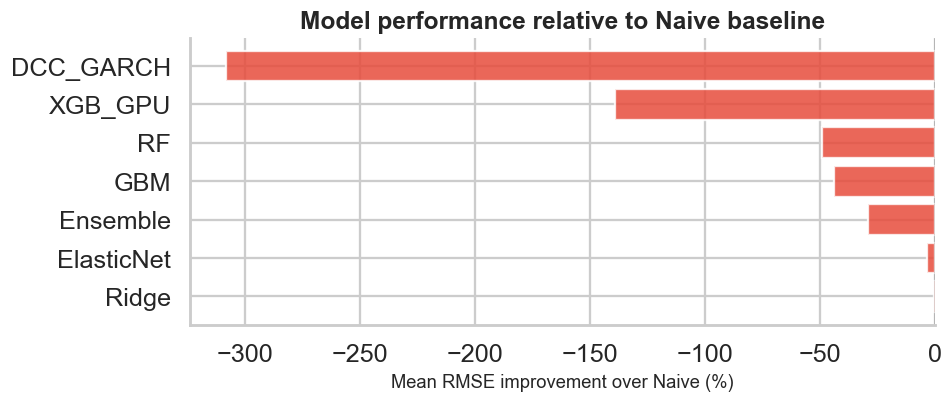

In [9]:
# ── Improvement over Naive baseline ─────────────────────────────────
naive_rmse = metrics[metrics['model'] == 'Naive_Last'].set_index('experiment')['RMSE']
improvement = []
for model in ML_MODELS + ['DCC_GARCH']:
    sub_m = metrics[metrics['model'] == model].set_index('experiment')
    common = sub_m.index.intersection(naive_rmse.index)
    if len(common) == 0:
        continue
    rel = ((naive_rmse[common] - sub_m.loc[common, 'RMSE']) / naive_rmse[common] * 100)
    improvement.append({'model': model, 'mean_improvement_%': rel.mean(), 'n': len(common)})

imp_df = pd.DataFrame(improvement).sort_values('mean_improvement_%', ascending=False)
print(imp_df.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in imp_df['mean_improvement_%']]
ax.barh(imp_df['model'], imp_df['mean_improvement_%'], color=colors, alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Mean RMSE improvement over Naive (%)')
ax.set_title('Model performance relative to Naive baseline')
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, 'model_improvement_over_naive.png'), dpi=130)
plt.show()


In [10]:
# ── LaTeX table ───────────────────────────────────────────────────
metrics_for_latex = metrics.rename(columns={'space': 'target_space'}).copy()
metrics_for_latex['dependency'] = metrics_for_latex['dependency'].str.replace('corr_', '', regex=False)
tex_path = os.path.join(paths.tables, 'model_comparison_full.tex')
metrics_to_latex(
    metrics_for_latex.sort_values(['dependency', 'window', 'RMSE']).head(80),
    tex_path,
    caption='Out-of-sample forecasting metrics (Fisher-z space).',
    label='tab:model_comparison',
)
print(f'LaTeX saved: {tex_path}')
print('Model comparison complete.')


LaTeX saved: D:\clear\outputs\tables\model_comparison_full.tex
Model comparison complete.
